# 07 生成模块与提示词工程第一部分：Context Assembler + Prompting 演示

> 本 notebook 对应 `schedule.md` 阶段 4–5（C0–C7）。
>
> 目标：
> 1. 从阶段 06 的检索结果读取候选文档块；
> 2. 用阶段 07 的 `ContextAssembler` 完成去重/多样化/控长组装；
> 3. 渲染四阶段医学提示模板；
> 4. 导出样例 JSON，供后续联调与回归使用；
> 5. 在 notebook 内运行单元测试并可视化，便于写报告。

---

## 你将看到什么

- **C0**：加载上游样例数据与模块（06 + 07）。
- **C1**：执行上下文组装，观察 metadata。
- **C2**：看“原始候选 vs 去重后 vs 多样化后”的差异。
- **C3**：看 token 上限对上下文长度和内容的影响。
- **C4**：将组装结果渲染成四阶段 Prompt（不调用 LLM）。
- **C5**：导出 `assembled_context_examples.json` 与 `prompt_examples.json`。
- **C6**：解读 C4/C5 输出与四阶段含义。
- **C7**：运行 `tests/` 单元测试 + 图表可视化 + 导出 `test_report.json`。

> 说明：本 notebook 默认使用 06 的离线样例 `pipeline_eval.json`，因此不依赖在线检索或大体积向量库。

## C0：加载数据与模块

这一步做三件事：

1. **定位目录**：确定 06（检索输出）和 07（本阶段代码）路径；
2. **导入模块**：`ContextAssembler` 与 `PROMPT_STAGES`；
3. **加载样例数据**：读取 06 的 `pipeline_eval.json`（样本库结果）。

> 为什么用离线样例？
>
> - 可复现：不依赖当下检索服务状态；
> - 轻量：无需重新连 Chroma/BM25；
> - 结构一致：与真实 `result["reranked"]` 字段相同。

In [40]:
from __future__ import annotations

import json
import sys
from pathlib import Path

# 项目根目录（当前 notebook 位于 07/notebooks）
ROOT = Path.cwd().resolve().parent.parent
STAGE06 = ROOT / "06 检索系统开发第二部分"
STAGE07 = ROOT / "07 生成模块与提示词工程第一部分"

# 将 07/src 加入路径，导入本阶段模块
sys.path.insert(0, str(STAGE07 / "src"))

from context_assembler import ContextAssembler
from prompts import PROMPT_STAGES, render_prompt_stage, validate_prompt_stage

PIPELINE_EVAL_PATH = STAGE06 / "outputs" / "samples" / "pipeline_eval.json"
with PIPELINE_EVAL_PATH.open("r", encoding="utf-8") as f:
    pipeline_eval = json.load(f)

print("ROOT:", ROOT)
print("Loaded:", PIPELINE_EVAL_PATH)
print("Query count:", pipeline_eval["query_count"])
print("Available prompt stages:", list(PROMPT_STAGES.keys()))

ROOT: D:\谷歌
Loaded: D:\谷歌\06 检索系统开发第二部分\outputs\samples\pipeline_eval.json
Query count: 5
Available prompt stages: ['evidence_evaluator', 'answer_generator', 'critical_reviewer', 'final_assembler']


## C1：ContextAssembler 组装 + metadata 展示

这一步对应任务书中的“上下文组装器核心产出”。

输入：`queries[0]["reranked"]`（以 `metformin cardiovascular effects` 为例）  
输出：

- `context_text`：给 LLM 的上下文正文；
- `metadata`：组装过程统计（候选数、去重后数、入选数、估算 token、来源分布）；
- `selected_chunks`：最终入选块（可追溯证据）。

> 这里先用 `tokenizer_name=None`，采用启发式 token 估算，避免首次运行触发 tokenizer 下载。

In [41]:
query_obj = pipeline_eval["queries"][0]
question = query_obj["query"]
retrieved_candidates = query_obj["reranked"]

assembler = ContextAssembler(tokenizer_name=None)
assembled = assembler.assemble(retrieved_candidates, max_context_tokens=1200)

print("Question:", question)
print("total_chunks_retrieved:", assembled.metadata.total_chunks_retrieved)
print("unique_chunks_after_dedup:", assembled.metadata.unique_chunks_after_dedup)
print("chunks_selected:", assembled.metadata.chunks_selected)
print("estimated_tokens:", assembled.metadata.estimated_tokens)
print("chunk_sources:", assembled.metadata.chunk_sources)
print("-" * 80)
print("Context preview:")
print(assembled.context_text[:700] + ("..." if len(assembled.context_text) > 700 else ""))

Question: metformin cardiovascular effects
total_chunks_retrieved: 5
unique_chunks_after_dedup: 5
chunks_selected: 3
estimated_tokens: 1200
chunk_sources: {'counts': {'PMC520826': 1, 'PMC521687': 1, 'PMC523844': 1}, 'unique_sources': 3}
--------------------------------------------------------------------------------
Context preview:
Daily rhythms in plasma levels of homocysteine

There is accumulated evidence that plasma concentration of the sulfur-containing amino-acid homocysteine (Hcy) is a prognostic marker for cardiovascular morbidity and mortality. Both fasting levels of Hcy and post methionine loading levels are used as prognostic markers. The aim of the present study was to investigate the existence of a daily rhythm in plasma Hcy under strictly controlled nutritional and sleep-wake conditions. We also investigated if the time during which methionine loading is performed, i.e., morning or evening, had a different effect on the resultant plasma Hcy concentration.
Six healthy men

## C2：去重 / 多样化前后对比

目的：让你直观看到 `ContextAssembler` 中两类策略的作用：

1. **去重（Jaccard）**：去掉内容过于重复的候选；
2. **多样化排序**：在相关性优先基础上，避免上下文被同一来源“刷屏”。

比较口径：

- 原始候选：06 `reranked`
- 去重后：`dedup_by_jaccard`
- 多样化后：`_order_with_diversity`（内部策略，演示用）

In [42]:
from models import coerce_to_document_chunks

chunks, skipped = coerce_to_document_chunks(retrieved_candidates)
unique_chunks = assembler.dedup_by_jaccard(chunks)
diverse_chunks = assembler._order_with_diversity(unique_chunks)  # 演示用

print("raw:", len(chunks), "| skipped_invalid:", skipped)
print("after_dedup:", len(unique_chunks))
print("after_diversity_order:", len(diverse_chunks))

print("\nTop-5 raw chunk_ids:")
print([c.chunk_id for c in chunks[:5]])

print("\nTop-5 after dedup chunk_ids:")
print([c.chunk_id for c in unique_chunks[:5]])

print("\nTop-5 after diversity order (chunk_id, source, score):")
for c in diverse_chunks[:5]:
    print((c.chunk_id, c.source[:70], round(c.relevance_score, 6)))

raw: 5 | skipped_invalid: 0
after_dedup: 5
after_diversity_order: 5

Top-5 raw chunk_ids:
['PMC520826', 'PMC521687', 'PMC523844', 'PMC523838_chunk2', 'PMC524175']

Top-5 after dedup chunk_ids:
['PMC520826', 'PMC521687', 'PMC523844', 'PMC523838_chunk2', 'PMC524175']

Top-5 after diversity order (chunk_id, source, score):
('PMC520826', 'Daily rhythms in plasma levels of homocysteine', 0.298591)
('PMC521687', 'Factors influencing preoperative stress response in coronary artery by', 0.280393)
('PMC523844', 'Distribution of Major Health Risks: Findings from the Global Burden of', 0.267694)
('PMC523838_chunk2', 'Nevirapine and Efavirenz Elicit Different Changes in Lipid Profiles in', 0.247805)
('PMC524175', 'Single nucleotide polymorphisms in the apolipoprotein B and low densit', 0.215493)


## C3：截断策略演示（token 限制 + 句号边界）

目的：验证“上下文长度受控”且“尽量在自然句子边界结束”。

做法：设置不同 `max_context_tokens`，观察：

- 最终 `estimated_tokens` 是否不超限；
- `context_text` 尾部是否较自然（优先在末 10% 找 `.`/`!`/`?`）。

> 提醒：若末 10% 区间本身没有句号，策略会退化为硬截断，这是设计上的可接受行为。

In [43]:
for limit in [300, 600, 1200]:
    out = assembler.assemble(retrieved_candidates, max_context_tokens=limit)
    text = out.context_text
    tail = text[-120:] if len(text) > 120 else text
    print(f"max_context_tokens={limit}")
    print("  estimated_tokens:", out.metadata.estimated_tokens)
    print("  chunks_selected:", out.metadata.chunks_selected)
    print("  ends_with_punct:", text.endswith((".", "!", "?")))
    print("  tail:", repr(tail))
    print()

max_context_tokens=300
  estimated_tokens: 286
  chunks_selected: 1
  ends_with_punct: True
  tail: 'wo experiments, subjects received every 3 hours 150 ml of specially designed low-protein liquid food (Ensure ® formula).'

max_context_tokens=600
  estimated_tokens: 600
  chunks_selected: 2
  ends_with_punct: False
  tail: 'ce it has been shown that even short-lasting sympathetic cardiovascular stimulation may have detrimental effects on pati'

max_context_tokens=1200
  estimated_tokens: 1200
  chunks_selected: 3
  ends_with_punct: False
  tail: 'increase cost-effectiveness.\nFor 26 selected risk factors, expert working groups conducted comprehensive reviews of data'



## C4：四阶段 Prompt 渲染示例（不调用 LLM）

这一步展示“提示工程模板”的直接使用方式：

- 输入：`question` + `assembled.context_text` + 通用约束 + 输出格式要求；
- 输出：四个阶段各自的 `system_prompt`、`user_prompt`、`temperature`、`max_tokens`。

你可以把这里的 payload 直接对接后续 LLM 调用层（LangChain/Ollama）。

In [44]:
constraints = (
    "Use only evidence in context. Do not fabricate citations. "
    "State uncertainty when evidence is weak or conflicting."
)
output_format = (
    "JSON with keys: answer, evidence_points, uncertainty, safety_note"
)

missing_report = {
    key: validate_prompt_stage(stage)
    for key, stage in PROMPT_STAGES.items()
}
print("Placeholder validation:", missing_report)

rendered_prompts = {
    key: render_prompt_stage(
        key,
        question=question,
        context=assembled.context_text,
        constraints=constraints,
        output_format=output_format,
    )
    for key in PROMPT_STAGES
}

for key, payload in rendered_prompts.items():
    print("=" * 100)
    print(key, "->", payload["stage"], "| temp=", payload["temperature"], "| max_tokens=", payload["max_tokens"])
    print("System:", payload["system_prompt"])
    preview = payload["user_prompt"][:600]
    print("User preview:\n", preview + ("..." if len(payload["user_prompt"]) > 600 else ""))

Placeholder validation: {'evidence_evaluator': [], 'answer_generator': [], 'critical_reviewer': [], 'final_assembler': []}
evidence_evaluator -> 证据评估器 | temp= 0.1 | max_tokens= 900
System: You are a medical evidence evaluator. Assess evidence quality and consistency conservatively.
User preview:
 Question:
metformin cardiovascular effects

Retrieved Context:
Daily rhythms in plasma levels of homocysteine

There is accumulated evidence that plasma concentration of the sulfur-containing amino-acid homocysteine (Hcy) is a prognostic marker for cardiovascular morbidity and mortality. Both fasting levels of Hcy and post methionine loading levels are used as prognostic markers. The aim of the present study was to investigate the existence of a daily rhythm in plasma Hcy under strictly controlled nutritional and sleep-wake conditions. We also investigated if the time during which methionine l...
answer_generator -> 答案生成器 | temp= 0.2 | max_tokens= 1200
System: You are a cautious medical assist

## C5：导出样例 JSON

导出两份文件到 `07/outputs/samples/`：

1. `assembled_context_examples.json`
   - 记录输入问题、组装统计、上下文预览、入选 chunk 摘要；
2. `prompt_examples.json`
   - 记录四阶段 prompt 的参数与内容（可用于后续调 LLM）。

这两份文件可用于：

- 回归测试（结构是否稳定）；
- 给后续 LangChain 链路做契约输入；
- 向老师/同学演示“检索结果如何进入生成前处理”。

In [45]:
OUTPUT_DIR = STAGE07 / "outputs" / "samples"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assembled_example = {
    "question": question,
    "input_source": str(PIPELINE_EVAL_PATH),
    "input_candidate_count": len(retrieved_candidates),
    "assembled": assembled.to_dict(),
    "context_preview": assembled.context_text[:1200],
    "selected_chunk_brief": [
        {
            "chunk_id": c.chunk_id,
            "source": c.source,
            "relevance_score": c.relevance_score,
            "doc_id": c.metadata.get("doc_id"),
        }
        for c in assembled.selected_chunks
    ],
}

prompt_example = {
    "question": question,
    "constraints": constraints,
    "output_format": output_format,
    "stages": rendered_prompts,
}

assembled_out = OUTPUT_DIR / "assembled_context_examples.json"
prompt_out = OUTPUT_DIR / "prompt_examples.json"

with assembled_out.open("w", encoding="utf-8") as f:
    json.dump(assembled_example, f, ensure_ascii=False, indent=2)

with prompt_out.open("w", encoding="utf-8") as f:
    json.dump(prompt_example, f, ensure_ascii=False, indent=2)

print("Exported:")
print(" -", assembled_out)
print(" -", prompt_out)

Exported:
 - D:\谷歌\07 生成模块与提示词工程第一部分\outputs\samples\assembled_context_examples.json
 - D:\谷歌\07 生成模块与提示词工程第一部分\outputs\samples\prompt_examples.json


## C6：输出分析（C4 打印结果 + C5 导出文件）

这一节帮你弄清：**屏幕上打印了什么**、**磁盘上保存了什么**、**各自有什么用**。

### C4 在屏幕上输出什么？

C4 **不调用 LLM**，只做两件事：

1. **`Placeholder validation`**：检查四个 Prompt 模板是否都包含 `{question}` `{context}` `{constraints}` `{output_format}`；空字典 `{}` 表示通过。
2. **四段 `rendered_prompts` 预览**：每个 stage 打印
   - `stage` 中文名（如「答案生成器」）
   - `temperature` / `max_tokens`（未来调 LLM 时的参数）
   - `system_prompt`（角色设定，较短）
   - `user_prompt` 前 600 字符预览（内含完整 question + context + 约束 + 任务说明；context 往往很长，所以只预览开头）

> **注意**：C4 输出的是「**准备发给 LLM 的输入**」，不是 LLM 生成的医学答案。

### 「四阶段 stages」是什么意思？是 LLM 可选模式吗？

**不是**让用户在聊天框里选「证据评估模式 / 答案模式」那种开关。

它们是 **医学 RAG 的多步 Prompt 剧本**：把一次问答拆成 4 个**不同角色**的 LLM 调用步骤，按顺序协作，降低胡编和安全风险。

| 英文 key | 中文名 | 这一步让 LLM 扮演什么 | 主要任务 | 设计意图 |
|----------|--------|----------------------|---------|---------|
| `evidence_evaluator` | 证据评估器 | 审稿人/文献员 | 从 context 里提炼证据、标强弱、找矛盾 | **先审证据**，不直接给临床建议 |
| `answer_generator` | 答案生成器 | 谨慎的医学助手 | 仅基于 context 起草答案并引用依据 | **写初稿** |
| `critical_reviewer` | 批判性审查器 | 安全审查员 | 挑过度断言、补风险提示、给修改意见 | **挑错纠偏**（医学场景重要） |
| `final_assembler` | 最终组装器 | 终稿编辑 | 合并初稿与审查意见，输出结构化终稿 | **定稿给用户看** |

```text
（未来全链路，示意）

context + question
    → ① evidence_evaluator   「这些证据质量如何？」
    → ② answer_generator     「根据证据写一版答案」
    → ③ critical_reviewer    「这版答案哪里不安全/不严谨？」
    → ④ final_assembler      「综合后给用户看的最终回答」
```

- **本周 C4**：只是把四份「剧本」都渲染出来给你看，**四次都还没真正调用 LLM**。
- **未来实现**：通常按 ①→②→③→④ **流水线串行**；后几步可把前几步的输出一并塞进 prompt（当前模板为简化，四步共用同一 `context`，未串联上一步 LLM 结果——后续 LangChain 可扩展）。
- **不是四选一**：不是「用户选一个模式就只跑那一个」；设计上是**整套流程**（也可在开发时单独测某一 stage）。

### C5 导出两份 JSON 各管什么？

| 文件 | 记录什么 | 主要用途 |
|------|---------|---------|
| `assembled_context_examples.json` | **组装层结果**：问题、输入来源、完整 `assembled`（context + metadata + selected_chunks）、context 前 1200 字预览、入选块摘要 | 检查「检索候选 → 上下文」这一步是否正确；程序侧溯源用了哪些 chunk |
| `prompt_examples.json` | **Prompt 层结果**：问题、constraints、output_format、四阶段完整 payload（含完整 `user_prompt`） | 后续 LangChain/Ollama 可直接读取；回归测试 Prompt 结构是否稳定 |

### 两份文件的关系

```text
assembled_context_examples.json
    └─ assembled.context_text  ──填进──▶  prompt_examples.json
                                              └─ stages.*.user_prompt 里的 Retrieved Context
```

下面用代码读取已导出文件，打印结构化摘要，便于你对照理解。

In [46]:
# --- 1) 分析 C4 内存中的 rendered_prompts（与屏幕打印同源）---
print("=" * 80)
print("【C4 输出分析】rendered_prompts（内存对象，共 4 个阶段）")
print("=" * 80)

for key, payload in rendered_prompts.items():
    user_len = len(payload["user_prompt"])
    ctx_marker = "Retrieved Context:"
    ctx_start = payload["user_prompt"].find(ctx_marker)
    ctx_end = payload["user_prompt"].find("\n\nConstraints:")
    ctx_snippet = (
        payload["user_prompt"][ctx_start:ctx_start + 80] + "..."
        if ctx_start >= 0
        else "(no context section)"
    )
    print(f"\n[{key}]")
    print(f"  阶段名: {payload['stage']}")
    print(f"  推理参数: temperature={payload['temperature']}, max_tokens={payload['max_tokens']}")
    print(f"  system_prompt 长度: {len(payload['system_prompt'])} 字符")
    print(f"  user_prompt 总长度: {user_len} 字符（C4 只预览前 600 字符）")
    if ctx_start >= 0 and ctx_end > ctx_start:
        context_in_prompt = payload["user_prompt"][ctx_start + len(ctx_marker) + 1 : ctx_end]
        print(f"  user_prompt 内嵌 context 长度: {len(context_in_prompt)} 字符")
        print(f"  与 assembled.context_text 一致: {context_in_prompt == assembled.context_text}")
    print(f"  context 片段: {ctx_snippet}")

# --- 2) 分析 C5 导出的 assembled_context_examples.json ---
print("\n" + "=" * 80)
print("【C5 文件 1】assembled_context_examples.json")
print("=" * 80)

with assembled_out.open("r", encoding="utf-8") as f:
    assembled_saved = json.load(f)

meta = assembled_saved["assembled"]["metadata"]
print("顶层字段:", list(assembled_saved.keys()))
print("question:", assembled_saved["question"])
print("input_source:", assembled_saved["input_source"])
print("input_candidate_count:", assembled_saved["input_candidate_count"])
print("组装统计:")
print("  total_chunks_retrieved:", meta["total_chunks_retrieved"])
print("  unique_chunks_after_dedup:", meta["unique_chunks_after_dedup"])
print("  chunks_selected:", meta["chunks_selected"])
print("  estimated_tokens:", meta["estimated_tokens"])
print("  chunk_sources:", meta["chunk_sources"])
print("context_text 总长度:", len(assembled_saved["assembled"]["context_text"]))
print("context_preview 长度:", len(assembled_saved["context_preview"]))
print("selected_chunks 条数:", len(assembled_saved["assembled"]["selected_chunks"]))
print("selected_chunk_brief（精简溯源表）:")
for i, item in enumerate(assembled_saved["selected_chunk_brief"], start=1):
    print(f"  [{i}] {item['chunk_id']} | score={item['relevance_score']} | {item['source'][:60]}...")

# --- 3) 分析 C5 导出的 prompt_examples.json ---
print("\n" + "=" * 80)
print("【C5 文件 2】prompt_examples.json")
print("=" * 80)

with prompt_out.open("r", encoding="utf-8") as f:
    prompt_saved = json.load(f)

print("顶层字段:", list(prompt_saved.keys()))
print("question:", prompt_saved["question"])
print("constraints:", prompt_saved["constraints"])
print("output_format:", prompt_saved["output_format"])
print("stages 包含:", list(prompt_saved["stages"].keys()))

for key, stage_payload in prompt_saved["stages"].items():
    print(f"\n  [{key}] -> {stage_payload['stage']}")
    print(f"    temperature={stage_payload['temperature']}, max_tokens={stage_payload['max_tokens']}")
    print(f"    user_prompt 长度={len(stage_payload['user_prompt'])}")

# --- 4) 跨文件一致性检查 ---
print("\n" + "=" * 80)
print("【一致性检查】两份导出文件是否对齐")
print("=" * 80)

ctx_from_assembled = assembled_saved["assembled"]["context_text"]
ctx_from_prompt = prompt_saved["stages"]["answer_generator"]["user_prompt"]
check_same_context = assembled.context_text in ctx_from_prompt
print("assembled.context_text 是否出现在 answer_generator.user_prompt 中:", check_same_context)
print("question 在两文件中一致:", assembled_saved["question"] == prompt_saved["question"])
print("constraints / output_format 已写入 prompt_examples:", bool(prompt_saved["constraints"] and prompt_saved["output_format"]))

print("\n【用途小结】")
print("- 要看「用了哪些文献块」→ assembled_context_examples.json 的 selected_chunk_brief / selected_chunks")
print("- 要看「将来发给 LLM 的完整提示词」→ prompt_examples.json 的 stages.*.user_prompt")
print("- 要看「组装过程统计」→ assembled_context_examples.json 的 assembled.metadata")
print("- C4 屏幕输出 = prompt_examples 的精简预览；真正完整内容以 JSON 文件为准")

【C4 输出分析】rendered_prompts（内存对象，共 4 个阶段）

[evidence_evaluator]
  阶段名: 证据评估器
  推理参数: temperature=0.1, max_tokens=900
  system_prompt 长度: 93 字符
  user_prompt 总长度: 5347 字符（C4 只预览前 600 字符）
  user_prompt 内嵌 context 长度: 4801 字符
  与 assembled.context_text 一致: True
  context 片段: Retrieved Context:
Daily rhythms in plasma levels of homocysteine

There is accu...

[answer_generator]
  阶段名: 答案生成器
  推理参数: temperature=0.2, max_tokens=1200
  system_prompt 长度: 94 字符
  user_prompt 总长度: 5324 字符（C4 只预览前 600 字符）
  user_prompt 内嵌 context 长度: 4801 字符
  与 assembled.context_text 一致: True
  context 片段: Retrieved Context:
Daily rhythms in plasma levels of homocysteine

There is accu...

[critical_reviewer]
  阶段名: 批判性审查器
  推理参数: temperature=0.0, max_tokens=800
  system_prompt 长度: 108 字符
  user_prompt 总长度: 5342 字符（C4 只预览前 600 字符）
  user_prompt 内嵌 context 长度: 4801 字符
  与 assembled.context_text 一致: True
  context 片段: Retrieved Context:
Daily rhythms in plasma levels of homocysteine

There is accu...

[final_assembl

## C7：单元测试运行与可视化

本节对应 `schedule.md` 阶段 5，把 `tests/` 里的 **16 项 pytest** 搬进 notebook：

1. **自动运行**：调用 `pytest tests/ -v`，解析每条用例的通过/失败；
2. **汇总表**：按测试文件分组，生成 DataFrame 便于写报告；
3. **图表**：通过率、各模块用例数、截断/token 曲线、Prompt 阶段参数；
4. **场景演示**：把关键测试逻辑「可视化」一遍（去重、阈值边界、句号截断等）；
5. **导出**：`outputs/samples/test_report.json` + `test_report_stdout.txt`，供后续正式报告引用。

> 与命令行等价：`conda activate med-rag-verify` → `cd 07...` → `pytest tests/ -v`

In [47]:
from __future__ import annotations

import os
import re
import subprocess
import sys
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore[assignment]

# 中文字体（Windows 常见）；若图表中文乱码可改为 SimHei 或删掉此行
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

ANSI_RE = re.compile(r"\x1b\[[0-9;]*m")


def strip_ansi(text: str) -> str:
    """去掉 pytest 在 notebook 子进程里常见的 ANSI 颜色码。"""
    return ANSI_RE.sub("", text)


TESTS_DIR = STAGE07 / "tests"
REPORT_DIR = STAGE07 / "outputs" / "samples"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# --- 1) 运行 pytest（禁用颜色，避免 [32mPASSED[0m 导致正则失效）---
pytest_env = os.environ.copy()
pytest_env["NO_COLOR"] = "1"
pytest_env["FORCE_COLOR"] = "0"

pytest_cmd = [
    sys.executable,
    "-m",
    "pytest",
    "tests",
    "-v",
    "--tb=line",
    "--color=no",
]
proc = subprocess.run(
    pytest_cmd,
    cwd=str(STAGE07),
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
    env=pytest_env,
)

stdout_clean = strip_ansi(proc.stdout)
stderr_clean = strip_ansi(proc.stderr)

stdout_path = REPORT_DIR / "test_report_stdout.txt"
stdout_path.write_text(stdout_clean + "\n" + stderr_clean, encoding="utf-8")

# 解析逐条结果：tests/test_dedup.py::test_xxx PASSED [  6%]
line_re = re.compile(
    r"(test_\w+\.py)::(\S+)\s+(PASSED|FAILED|SKIPPED|ERROR)",
)
records: list[dict] = []
for match in line_re.finditer(stdout_clean):
    module = match.group(1).replace(".py", "")
    records.append(
        {
            "module": module,
            "test_name": match.group(2),
            "status": match.group(3),
            "passed": match.group(3) == "PASSED",
        }
    )

# 解析汇总行：16 passed in 0.05s 或 14 passed, 2 failed
summary_re = re.search(r"(\d+)\s+passed(?:,\s+(\d+)\s+failed)?", stdout_clean)
passed_count = int(summary_re.group(1)) if summary_re else sum(r["passed"] for r in records)
failed_count = int(summary_re.group(2) or 0) if summary_re else sum(not r["passed"] for r in records)
exit_code = proc.returncode

df_tests = pd.DataFrame(records)
if df_tests.empty:
    print("【警告】未能从 pytest 输出解析到用例，请打开 test_report_stdout.txt 检查。")
    print("stdout 前 500 字符:\n", stdout_clean[:500])
else:
    print(f"pytest exit_code={exit_code} | parsed={len(df_tests)} | passed={passed_count} | failed={failed_count}")
print(f"stdout 已保存: {stdout_path}")
display(df_tests)

if failed_count:
    print("\n【失败用例详情】\n")
    print(stdout_clean[stdout_clean.find("FAILURES") :] if "FAILURES" in stdout_clean else stdout_clean)

pytest exit_code=0 | parsed=16 | passed=16 | failed=0
stdout 已保存: D:\谷歌\07 生成模块与提示词工程第一部分\outputs\samples\test_report_stdout.txt


,module,test_name,status,passed
0,test_dedup,test_dedup_keeps_higher_relevance_chunk,PASSED,True
1,test_dedup,test_dedup_respects_threshold_boundary,PASSED,True
2,test_dedup,test_dedup_keeps_both_when_dissimilar,PASSED,True
3,test_dedup,test_dedup_empty_list,PASSED,True
4,test_dedup,test_coerce_skips_invalid_text,PASSED,True
5,test_dedup,test_diversity_penalizes_same_doc_id,PASSED,True
6,test_prompts,test_prompt_stages_keys_complete,PASSED,True
7,test_prompts,test_prompt_stage_fields_present,PASSED,True
8,test_prompts,test_all_placeholders_in_templates,PASSED,True
9,test_prompts,test_render_prompt_stage_fills_values,PASSED,True


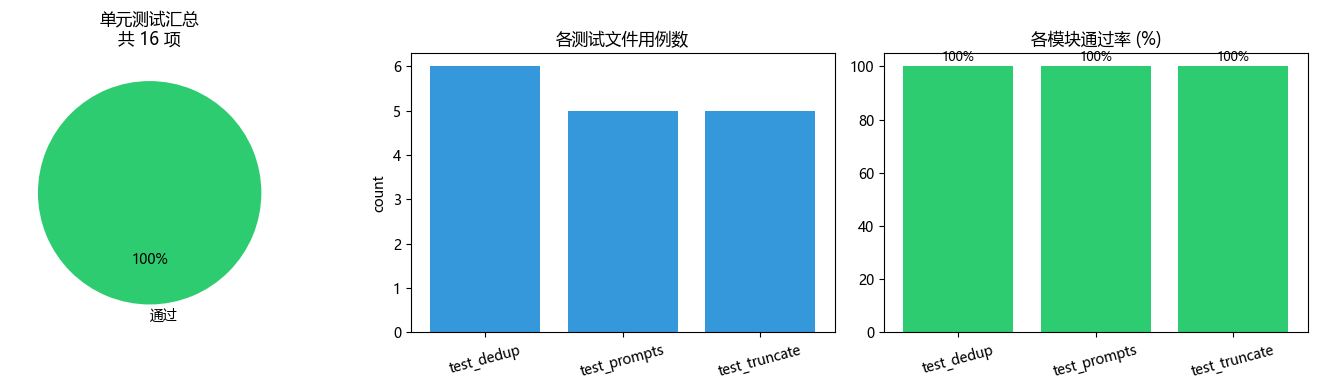

图表已保存: D:\谷歌\07 生成模块与提示词工程第一部分\outputs\samples\test_summary_charts.png


In [48]:
# --- 2) 测试汇总可视化 ---
# 若只跑了本格、未跑 C7-1，尝试从已保存的 stdout 重新解析
if "df_tests" not in globals() or df_tests.empty or "module" not in df_tests.columns:
    _stdout_path = STAGE07 / "outputs" / "samples" / "test_report_stdout.txt"
    if _stdout_path.exists():
        _text = ANSI_RE.sub("", _stdout_path.read_text(encoding="utf-8"))
        _records = [
            {
                "module": m.group(1).replace(".py", ""),
                "test_name": m.group(2),
                "status": m.group(3),
                "passed": m.group(3) == "PASSED",
            }
            for m in re.finditer(
                r"(test_\w+\.py)::(\S+)\s+(PASSED|FAILED|SKIPPED|ERROR)",
                _text,
            )
        ]
        if _records:
            df_tests = pd.DataFrame(_records)
            _summary = re.search(r"(\d+)\s+passed(?:,\s+(\d+)\s+failed)?", _text)
            passed_count = int(_summary.group(1)) if _summary else int(df_tests["passed"].sum())
            failed_count = int(_summary.group(2) or 0) if _summary else int((~df_tests["passed"]).sum())
            print(f"已从 {_stdout_path.name} 重新解析 {len(df_tests)} 条用例")

if df_tests.empty or "module" not in df_tests.columns:
    raise RuntimeError(
        "df_tests 为空，无法绘图。请先运行 C7-1，"
        "并确认 test_report_stdout.txt 中有 PASSED 行。"
    )

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 2a) 总体通过/失败饼图
axes[0].pie(
    [passed_count, failed_count] if failed_count else [passed_count],
    labels=(["通过", "失败"] if failed_count else ["通过"]),
    colors=(["#2ecc71", "#e74c3c"] if failed_count else ["#2ecc71"]),
    autopct="%1.0f%%",
    startangle=90,
)
axes[0].set_title(f"单元测试汇总\n共 {len(df_tests)} 项")

# 2b) 各模块用例数
module_counts = df_tests.groupby("module").size().sort_index()
axes[1].bar(module_counts.index, module_counts.values, color="#3498db")
axes[1].set_title("各测试文件用例数")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=15)

# 2c) 各模块通过率
module_pass = df_tests.groupby("module")["passed"].mean() * 100
colors = ["#2ecc71" if v == 100 else "#e74c3c" for v in module_pass.values]
axes[2].bar(module_pass.index, module_pass.values, color=colors)
axes[2].set_ylim(0, 105)
axes[2].set_title("各模块通过率 (%)")
axes[2].tick_params(axis="x", rotation=15)
for i, v in enumerate(module_pass.values):
    axes[2].text(i, v + 2, f"{v:.0f}%", ha="center", fontsize=9)

plt.tight_layout()
chart_summary_path = REPORT_DIR / "test_summary_charts.png"
plt.savefig(chart_summary_path, dpi=150, bbox_inches="tight")
plt.show()
print("图表已保存:", chart_summary_path)

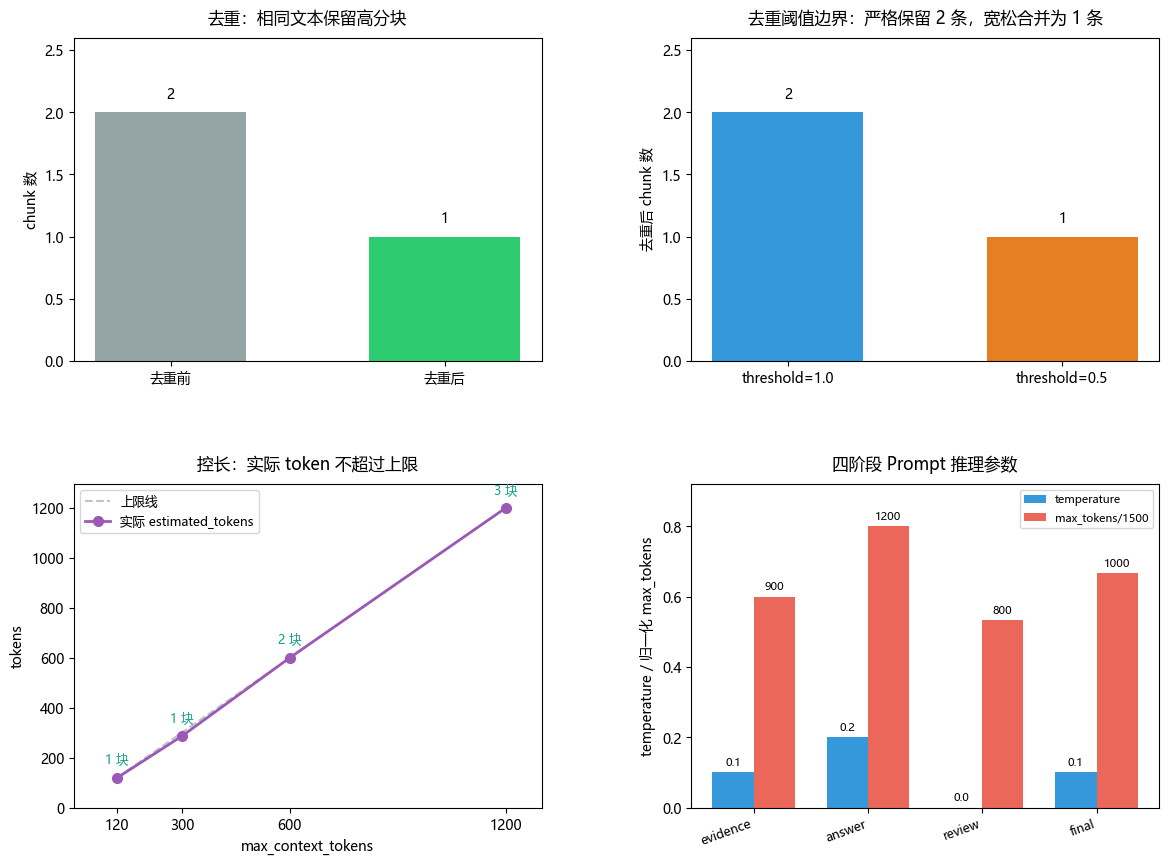

场景图已保存: D:\谷歌\07 生成模块与提示词工程第一部分\outputs\samples\test_scenario_charts.png

【占位符校验】True=已包含


,question,context,constraints,output_format
evidence_evaluator,True,True,True,True
answer_generator,True,True,True,True
critical_reviewer,True,True,True,True
final_assembler,True,True,True,True


In [49]:
# --- 3) 关键测试场景可视化（与 tests/ 一一对应，便于写报告）---
from models import DocumentChunk

asm_demo = ContextAssembler(tokenizer_name=None)

STAGE_SHORT = {
    "evidence_evaluator": "evidence",
    "answer_generator": "answer",
    "critical_reviewer": "review",
    "final_assembler": "final",
}


def _demo_chunk(text: str, score: float, cid: str, doc_id: str | None = None) -> DocumentChunk:
    return DocumentChunk(
        text=text,
        metadata={"doc_id": doc_id or cid},
        relevance_score=score,
        source=f"demo-{cid}",
        chunk_id=cid,
    )


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(hspace=0.38, wspace=0.32)

# 3a) 去重：相同文本保留高分（test_dedup_keeps_higher_relevance_chunk）
ax = axes[0, 0]
dup_text = "metformin cardiovascular effects trial results showed improvement"
dup_chunks = [
    _demo_chunk(dup_text, 0.5, "c2"),
    _demo_chunk(dup_text, 1.0, "c1"),
]
before = len(dup_chunks)
after = len(asm_demo.dedup_by_jaccard(dup_chunks))
ax.bar(["去重前", "去重后"], [before, after], color=["#95a5a6", "#2ecc71"], width=0.55)
ax.set_title("去重：相同文本保留高分块", pad=10)
ax.set_ylabel("chunk 数")
ax.set_ylim(0, max(before, after) + 0.6)
for i, v in enumerate([before, after]):
    ax.text(i, v + 0.08, str(v), ha="center", va="bottom")

# 3b) 阈值边界（test_dedup_respects_threshold_boundary）
ax = axes[0, 1]
text_a = "warfarin dosing elderly patients atrial fibrillation guidelines"
text_b = text_a + " revised"
pair = [_demo_chunk(text_a, 1.0, "c1"), _demo_chunk(text_b, 0.5, "c2")]
strict_n = len(ContextAssembler(tokenizer_name=None, dedup_threshold=1.0).dedup_by_jaccard(pair))
loose_n = len(ContextAssembler(tokenizer_name=None, dedup_threshold=0.5).dedup_by_jaccard(pair))
ax.bar(["threshold=1.0", "threshold=0.5"], [strict_n, loose_n], color=["#3498db", "#e67e22"], width=0.55)
ax.set_title("去重阈值边界：严格保留 2 条，宽松合并为 1 条", pad=10)
ax.set_ylabel("去重后 chunk 数")
ax.set_ylim(0, max(strict_n, loose_n) + 0.6)
for i, v in enumerate([strict_n, loose_n]):
    ax.text(i, v + 0.08, str(v), ha="center", va="bottom")

# 3c) token 上限 vs 实际估算（同一数值 x 轴，入选块数用标注避免双轴重叠）
ax = axes[1, 0]
limits = [120, 300, 600, 1200]
actual = []
selected = []
for lim in limits:
    out = asm_demo.assemble(retrieved_candidates, max_context_tokens=lim)
    actual.append(out.metadata.estimated_tokens)
    selected.append(out.metadata.chunks_selected)

ax.plot(limits, limits, "--", color="#bdc3c7", label="上限线", linewidth=1.5)
ax.plot(limits, actual, "o-", color="#9b59b6", label="实际 estimated_tokens", linewidth=2, markersize=7)
for lim, tok, n in zip(limits, actual, selected):
    ax.annotate(
        f"{n} 块",
        (lim, tok),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        color="#16a085",
    )
ax.set_xticks(limits)
ax.set_xticklabels([str(v) for v in limits])
ax.set_xlabel("max_context_tokens")
ax.set_ylabel("tokens")
ax.set_title("控长：实际 token 不超过上限", pad=10)
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(0, 1300)
ax.set_ylim(0, max(limits) * 1.08)

# 3d) 四阶段 Prompt 参数（单轴分组柱，避免双 y 轴挤压）
ax = axes[1, 1]
stage_keys = list(PROMPT_STAGES.keys())
temps = [PROMPT_STAGES[k].temperature for k in stage_keys]
max_toks = [PROMPT_STAGES[k].max_tokens for k in stage_keys]
x = list(range(len(stage_keys)))
w = 0.36
ax.bar([i - w / 2 for i in x], temps, width=w, label="temperature", color="#3498db")
ax.bar([i + w / 2 for i in x], [m / 1500 for m in max_toks], width=w, label="max_tokens/1500", color="#e74c3c", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([STAGE_SHORT[k] for k in stage_keys], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("temperature / 归一化 max_tokens")
ax.set_title("四阶段 Prompt 推理参数", pad=10)
for i, (t, m) in enumerate(zip(temps, max_toks)):
    ax.text(i - w / 2, t + 0.01, f"{t}", ha="center", va="bottom", fontsize=8)
    ax.text(i + w / 2, m / 1500 + 0.01, f"{m}", ha="center", va="bottom", fontsize=8)
ax.legend(loc="upper right", fontsize=8)
ax.set_ylim(0, max(max(m / 1500 for m in max_toks), max(temps)) + 0.12)

plt.savefig(REPORT_DIR / "test_scenario_charts.png", dpi=150, bbox_inches="tight", pad_inches=0.25)
chart_scenarios_path = REPORT_DIR / "test_scenario_charts.png"
plt.show()
print("场景图已保存:", chart_scenarios_path)

# 占位符校验热力表
placeholder_matrix = pd.DataFrame(
    {
        key: {
            ph: (ph not in validate_prompt_stage(stage))
            for ph in ["question", "context", "constraints", "output_format"]
        }
        for key, stage in PROMPT_STAGES.items()
    }
).T
print("\n【占位符校验】True=已包含")
display(placeholder_matrix)

In [50]:
# --- 4) 导出结构化测试报告 JSON ---
test_report = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "pytest_exit_code": exit_code,
    "summary": {
        "total": len(df_tests),
        "passed": passed_count,
        "failed": failed_count,
        "pass_rate": round(100 * passed_count / max(len(df_tests), 1), 1),
    },
    "by_module": (
        df_tests.groupby("module")
        .agg(total=("test_name", "count"), passed=("passed", "sum"))
        .assign(failed=lambda d: d["total"] - d["passed"])
        .reset_index()
        .to_dict(orient="records")
    ),
    "cases": records,
    "artifacts": {
        "stdout": str(stdout_path),
        "summary_chart": str(chart_summary_path),
        "scenario_chart": str(chart_scenarios_path),
    },
    "notes": (
        "与 tests/test_dedup.py、test_truncate.py、test_prompts.py 对应；"
        "写正式报告时可引用 summary_chart / scenario_chart 与 cases 列表。"
    ),
}

report_json_path = REPORT_DIR / "test_report.json"
with report_json_path.open("w", encoding="utf-8") as f:
    json.dump(test_report, f, ensure_ascii=False, indent=2)

print("已导出:", report_json_path)
print("报告摘要:")
print(f"  通过率: {test_report['summary']['pass_rate']}%")
print(f"  模块: {[m['module'] for m in test_report['by_module']]}")
print("\n【写报告时可引用】")
print("- 通过率饼图 / 模块柱状图 → test_summary_charts.png")
print("- 去重/阈值/控长/Prompt 参数 → test_scenario_charts.png")
print("- 逐条用例明细 → test_report.json 的 cases")
print("- 完整 pytest 日志 → test_report_stdout.txt")

已导出: D:\谷歌\07 生成模块与提示词工程第一部分\outputs\samples\test_report.json
报告摘要:
  通过率: 100.0%
  模块: ['test_dedup', 'test_prompts', 'test_truncate']

【写报告时可引用】
- 通过率饼图 / 模块柱状图 → test_summary_charts.png
- 去重/阈值/控长/Prompt 参数 → test_scenario_charts.png
- 逐条用例明细 → test_report.json 的 cases
- 完整 pytest 日志 → test_report_stdout.txt
